# F1500W JWST/MIRI Imaging Pipeline — SMC-SW-Bar-3 (GO-5952)

Custom data reduction for JWST/MIRI F1500W (15.0 µm) imaging.

WCS alignment uses shifts measured from F560W (see `F560W_pipeline.ipynb`).

**Pipeline:** Stage 1 → fix_rateints → Stage 2 → apply F560W shifts → Lyot flag → Stage 3

## 1. Configuration

In [1]:
# ═══════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════

# ─── Target ───────────────────────────────────────────────
FILT           = 'F1500W'
TARGET         = 'SMC-SW-Bar-3'
PROGRAM        = 'GO-5952'

# ─── Paths ────────────────────────────────────────────────
BASE_DIR       = '/Users/melyajou/SMC_GO5952/miri'
TILE1_BASE     = 'jw05952003001'          # tile 1 observation ID
TILE2_BASE     = 'jw05952003002'          # tile 2 observation ID

# ─── WCS shifts (arcsec) ─────────────────────────────────
# Measured from F560W alignment; applied to each tile
# before Stage 3 to correct absolute astrometry.
TILE1_SHIFTS   = [-0.1674, -0.1364]       # [delta_RA, delta_Dec]
TILE2_SHIFTS   = [-0.1584, -0.1352]

# ─── Lyot coronagraph artifact ───────────────────────────
LYOT_ROW       = 700
LYOT_COL       = 310

# ─── Stage 1 options ─────────────────────────────────────
IPC_SKIP       = True       # skip IPC correction (Karl's practice)
JUMP_THRESHOLD = 5.0        # sigma for jump detection (MAST uses 4.0)

# ─── Run flags ────────────────────────────────────────────
run_detector1  = False      # Stage 1: detector1 + fix_rateints
run_image2     = True      # Stage 2: image2 calibration
run_image3     = True       # Stage 3: final mosaic

# ─── Stage 3 options ─────────────────────────────────────
TWEAKREG       = False      # skip — WCS shifts already applied above
SKYMATCH       = False       # match sky levels between exposures
                            # NOTE: unreliable if overlaps contain bright extended emission
SKY_SUBTRACT   = False      # offset only, do not subtract
OUTLIER_DET    = True       # outlier rejection ON
PIXEL_SCALE    = 0.11       # output pixel scale (arcsec/pix)
PIXFRAC        = 1.0        # drizzle pixel fraction
KERNEL         = 'square'

# ─── Figures ─────────────────────────────────────────────
FIGSIZE_SINGLE = (12, 10)
FIGSIZE_DOUBLE = (22, 10)
CMAP           = 'afmhot'
FIG_DPI        = 200

## 2. Setup

In [2]:
import os, sys, glob, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import logging

logging.getLogger('stpipe').setLevel(logging.WARNING)
logging.getLogger('CRDS').setLevel(logging.WARNING)

os.environ['CRDS_PATH']       = '/Users/melyajou/SMC_GO5952/crds_cache'
os.environ['CRDS_SERVER_URL'] = 'https://jwst-crds.stsci.edu'

from astropy.io import fits
from astropy.stats import sigma_clipped_stats, sigma_clip
from astropy.visualization import simple_norm
from jwst import datamodels
from jwst.datamodels import dqflags
from jwst.pipeline import calwebb_detector1, calwebb_image2, calwebb_image3
from jwst.associations import asn_from_list
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base

sys.path.insert(0, '..')
from pipeline_utils import *

# Directories
stage0   = f'{BASE_DIR}/{FILT}/stage0'
stage1   = f'{BASE_DIR}/{FILT}/stage1'
stage2   = f'{BASE_DIR}/{FILT}/stage2'
stage3   = f'{BASE_DIR}/{FILT}/stage3'
fig_dir  = f'{BASE_DIR}/{FILT}/figures'
mast_dir = f'{BASE_DIR}/{FILT}/mast_reference'

for d in [stage0, stage1, stage2, stage3, fig_dir]:
    os.makedirs(d, exist_ok=True)

print(f'{TARGET} ({PROGRAM}) — {FILT}')

SMC-SW-Bar-3 (GO-5952) — F1500W


## 3. Stage 1 — Detector1 + fix_rateints

Ramp fitting on uncal files, then fix the rate/rateints averaging bug (Gordon).

In [3]:
uncal_files = sorted(glob.glob(f'{stage0}/*_uncal.fits'))
print(f'{len(uncal_files)} uncal files in stage0/')

if run_detector1:
    existing_rate = sorted(glob.glob(f'{stage1}/*_rate.fits'))
    if len(existing_rate) == len(uncal_files):
        print(f'Stage 1 already done: {len(existing_rate)} rate files -- skipping')
    else:
        print(f'Running Stage 1 on {len(uncal_files)} uncal files...')
        for i, f in enumerate(uncal_files):
            tile = 'T1' if TILE1_BASE in f else 'T2'
            print(f'  [{i+1}/{len(uncal_files)}] {tile} -- {os.path.basename(f)}')
            t0 = time.time()
            det1_dict = {
                'ipc': {'skip': IPC_SKIP},
                'jump': {'rejection_threshold': JUMP_THRESHOLD, 'maximum_cores': 'half'},
                'ramp_fit': {'maximum_cores': 'half'},
            }
            calwebb_detector1.Detector1Pipeline.call(
                f, steps=det1_dict, output_dir=stage1, save_results=True)
            print(f'    done in {(time.time()-t0)/60:.1f} min')

    # fix_rateints
    rate_files = sorted(glob.glob(f'{stage1}/*_rate.fits'))
    old_fixed = glob.glob(f'{stage1}/*_fixed_rate.fits') + glob.glob(f'{stage1}/*_fixed_rateints.fits')
    for f in old_fixed:
        os.remove(f)
    print(f'\nRunning fix_rateints on {len(rate_files)} files...')
    for f in rate_files:
        out = fix_rateints_to_rate(f)
        print(f'  {os.path.basename(f)} -> {os.path.basename(out)}')
else:
    print('Skipping Stage 1 (run_detector1 = False)')

fixed_rate_files = sorted(glob.glob(f'{stage1}/*_fixed_rate.fits'))
print(f'\n{len(fixed_rate_files)} fixed_rate files ready')

8 uncal files in stage0/
Skipping Stage 1 (run_detector1 = False)

8 fixed_rate files ready


## 4. Stage 2 — Image2 (Flat Field + Photometric Calibration)

Resample skipped — drizzle happens in Stage 3.

In [4]:
if run_image2:
    old_cal = glob.glob(f'{stage2}/*_cal.fits') + glob.glob(f'{stage2}/*_i2d.fits')
    for f in old_cal:
        os.remove(f)

    print(f'Running Stage 2 on {len(fixed_rate_files)} files...')
    for i, f in enumerate(fixed_rate_files):
        print(f'  [{i+1}/{len(fixed_rate_files)}] {os.path.basename(f)}')
        calwebb_image2.Image2Pipeline.call(
            f, steps={'resample': {'skip': True}},
            output_dir=stage2, save_results=True)
else:
    print('Skipping Stage 2 (run_image2 = False)')

cal_files = sorted(glob.glob(f'{stage2}/*_cal.fits'))
print(f'{len(cal_files)} cal files ready')

Running Stage 2 on 8 files...
  [1/8] jw05952003001_10101_00001_mirimage_fixed_rate.fits


2026-03-28 04:44:45,833 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pars-resamplestep_0001.asdf
2026-03-28 04:44:45,840 - stpipe.pipeline - INFO - PARS-IMAGE2PIPELINE parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pars-image2pipeline_0004.asdf
2026-03-28 04:44:45,847 - stpipe.step - INFO - Image2Pipeline instance created.
2026-03-28 04:44:45,848 - stpipe.step - INFO - BackgroundStep instance created.
2026-03-28 04:44:45,848 - stpipe.step - INFO - AssignWcsStep instance created.
2026-03-28 04:44:45,849 - stpipe.step - INFO - FlatFieldStep instance created.
2026-03-28 04:44:45,849 - stpipe.step - INFO - PhotomStep instance created.
2026-03-28 04:44:45,850 - stpipe.step - INFO - ResampleStep instance created.
2026-03-28 04:44:45,915 - stpipe.step - INFO - Step Image2Pipeline running with args ('/Users/melyajou/SMC_GO5952/miri/F1500W/stage1/jw05952003001_10101_00001_m

  [2/8] jw05952003001_10101_00002_mirimage_fixed_rate.fits


2026-03-28 04:44:47,090 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(1024, 1032) from /Users/melyajou/SMC_GO5952/miri/F1500W/stage2/jw05952003001_10101_00002_mirimage_fixed_image2pipeline.fits>,).
2026-03-28 04:44:47,149 - jwst.assign_wcs.miri - INFO - Created a MIRI mir_image pipeline with references {'distortion': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_distortion_0047.asdf', 'filteroffset': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_filteroffset_0008.asdf', 'specwcs': None, 'regions': None, 'wavelengthrange': None, 'camera': None, 'collimator': None, 'disperser': None, 'fore': None, 'fpa': None, 'msa': None, 'ote': None, 'ifupost': None, 'ifufore': None, 'ifuslicer': None}
2026-03-28 04:44:47,178 - stcal.alignment.util - INFO - Update S_REGION to POLYGON ICRS  11.388476596 -73.365651291 11.283438191 -73.374299113 11.313613150 -73.404508832 11.419276002 -73.396109431
2026-03-28 04:44:47,179 - jwst.assig

  [3/8] jw05952003001_10101_00003_mirimage_fixed_rate.fits


...

  [7/8] jw05952003002_10101_00003_mirimage_fixed_rate.fits


2026-03-28 04:44:51,030 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(1024, 1032) from /Users/melyajou/SMC_GO5952/miri/F1500W/stage2/jw05952003002_10101_00003_mirimage_fixed_image2pipeline.fits>,).
2026-03-28 04:44:51,089 - jwst.assign_wcs.miri - INFO - Created a MIRI mir_image pipeline with references {'distortion': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_distortion_0047.asdf', 'filteroffset': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_filteroffset_0008.asdf', 'specwcs': None, 'regions': None, 'wavelengthrange': None, 'camera': None, 'collimator': None, 'disperser': None, 'fore': None, 'fpa': None, 'msa': None, 'ote': None, 'ifupost': None, 'ifufore': None, 'ifuslicer': None}
2026-03-28 04:44:51,122 - stcal.alignment.util - INFO - Update S_REGION to POLYGON ICRS  11.373370444 -73.352244164 11.268407034 -73.360884702 11.298532774 -73.391096491 11.404119822 -73.382704429
2026-03-28 04:44:51,123 - jwst.assig

  [8/8] jw05952003002_10101_00004_mirimage_fixed_rate.fits


2026-03-28 04:44:51,914 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(1024, 1032) from /Users/melyajou/SMC_GO5952/miri/F1500W/stage2/jw05952003002_10101_00004_mirimage_fixed_image2pipeline.fits>,).
2026-03-28 04:44:51,981 - jwst.assign_wcs.miri - INFO - Created a MIRI mir_image pipeline with references {'distortion': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_distortion_0047.asdf', 'filteroffset': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_filteroffset_0008.asdf', 'specwcs': None, 'regions': None, 'wavelengthrange': None, 'camera': None, 'collimator': None, 'disperser': None, 'fore': None, 'fpa': None, 'msa': None, 'ote': None, 'ifupost': None, 'ifufore': None, 'ifuslicer': None}
2026-03-28 04:44:52,018 - stcal.alignment.util - INFO - Update S_REGION to POLYGON ICRS  11.360624296 -73.352575689 11.255652420 -73.361209792 11.285756102 -73.391423427 11.391351480 -73.383037838
2026-03-28 04:44:52,019 - jwst.assig

8 cal files ready


## 5. Apply F560W WCS Shifts

F560W (shortest wavelength) has the most point sources for tweakreg alignment.
We reuse those shifts for all other MIRI filters.

In [5]:
# ─── Apply F560W shifts to cal files ─────────────────────
for f in glob.glob(f'{stage2}/*_wcs_cal.fits'):
    os.remove(f)

print(f'Applying F560W shifts:')
print(f'  T1: {TILE1_SHIFTS}')
print(f'  T2: {TILE2_SHIFTS}\n')

for cfile in cal_files:
    if TILE1_BASE in cfile:
        s, tile = TILE1_SHIFTS, 'T1'
    else:
        s, tile = TILE2_SHIFTS, 'T2'
    outfile = shift_wcs(cfile, s, "_wcs")
    print(f'  {tile}: {os.path.basename(outfile)}')

wcs_cal_files = sorted(glob.glob(f'{stage2}/*_wcs_cal.fits'))
print(f'\n{len(wcs_cal_files)} WCS-corrected cal files')

Applying F560W shifts:
  T1: [-0.1674, -0.1364]
  T2: [-0.1584, -0.1352]

  T1: jw05952003001_10101_00001_mirimage_fixed_wcs_cal.fits
  T1: jw05952003001_10101_00002_mirimage_fixed_wcs_cal.fits
  T1: jw05952003001_10101_00003_mirimage_fixed_wcs_cal.fits
  T1: jw05952003001_10101_00004_mirimage_fixed_wcs_cal.fits
  T2: jw05952003002_10101_00001_mirimage_fixed_wcs_cal.fits
  T2: jw05952003002_10101_00002_mirimage_fixed_wcs_cal.fits
  T2: jw05952003002_10101_00003_mirimage_fixed_wcs_cal.fits
  T2: jw05952003002_10101_00004_mirimage_fixed_wcs_cal.fits

8 WCS-corrected cal files


## 6. Lyot Flag + Stage 3 — Final Mosaic

In [6]:
# ─── Flag Lyot ───────────────────────────────────────────
wcs_cal_files = sorted(glob.glob(f'{stage2}/*_wcs_cal.fits'))
for f in wcs_cal_files:
    flag_lyot(f, lyot_row=LYOT_ROW, lyot_col=LYOT_COL)
print(f'Lyot flagged in {len(wcs_cal_files)} files')

Lyot flagged in 8 files


In [7]:
# ─── Stage 3 — Final mosaic ──────────────────────────────
if run_image3:
    old_s3 = glob.glob(f'{stage3}/*')
    for f in old_s3:
        os.remove(f)

    asn_name = f'miri_{FILT}_final'
    asn = asn_from_list.asn_from_list(
        wcs_cal_files, rule=DMS_Level3_Base, product_name=asn_name)
    asn_file = f'{stage3}/{asn_name}.json'
    with open(asn_file, 'w') as fp:
        name, serialized = asn.dump(format='json')
        fp.write(serialized)

    im3_dict = {
        'tweakreg':          {'skip': not TWEAKREG},
        'skymatch':          {'skymethod': 'match', 'subtract': SKY_SUBTRACT, 'skip': not SKYMATCH},
        'outlier_detection': {'skip': not OUTLIER_DET, 'save_results': True},
        'resample':          {'kernel': KERNEL, 'pixel_scale': PIXEL_SCALE, 'pixfrac': PIXFRAC},
    }

    print('Running Stage 3 (final mosaic)...')
    calwebb_image3.Image3Pipeline.call(
        asn_file, steps=im3_dict, output_dir=stage3, save_results=True)
    print('Stage 3 complete')
else:
    print('Skipping Stage 3 (run_image3 = False)')

mosaic = sorted(glob.glob(f'{stage3}/*_i2d.fits'))[0]
print(f'Mosaic: {mosaic}')

/Users/melyajou/miniforge3/envs/jwst/lib/python3.11/site-packages/jwst/associations/association.py:234: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)
2026-03-28 04:44:55,668 - stpipe.step - INFO - PARS-TWEAKREGSTEP parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pars-tweakregstep_0014.asdf
2026-03-28 04:44:55,675 - stpipe.step - INFO - PARS-OUTLIERDETECTIONSTEP parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pars-outlierdetectionstep_0095.asdf
2026-03-28 04:44:55,680 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pars-resamplestep_0001.asdf
2026-03-28 04:44:55,684 - stpipe.step - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pa

Running Stage 3 (final mosaic)...


2026-03-28 04:44:55,696 - stpipe.step - INFO - SkyMatchStep instance created.
2026-03-28 04:44:55,696 - stpipe.step - INFO - OutlierDetectionStep instance created.
2026-03-28 04:44:55,697 - stpipe.step - INFO - ResampleStep instance created.
2026-03-28 04:44:55,698 - stpipe.step - INFO - SourceCatalogStep instance created.
2026-03-28 04:44:55,785 - stpipe.step - INFO - Step Image3Pipeline running with args ('/Users/melyajou/SMC_GO5952/miri/F1500W/stage3/miri_F1500W_final.json',).
2026-03-28 04:44:55,795 - stpipe.step - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir: /Users/melyajou/SMC_GO5952/miri/F1500W/stage3
  output_ext: .fits
  output_use_model: False
  output_use_index: True
  save_results: True
  skip: False
  suffix: None
  search_output_file: True
  input_dir: ''
  in_memory: True
  steps:
    assign_mtwcs:
      pre_hooks: []
      post_hooks: []
      output_file: None
      output_dir: None
      output_ext: .fit

Stage 3 complete
Mosaic: /Users/melyajou/SMC_GO5952/miri/F1500W/stage3/miri_F1500W_final_i2d.fits


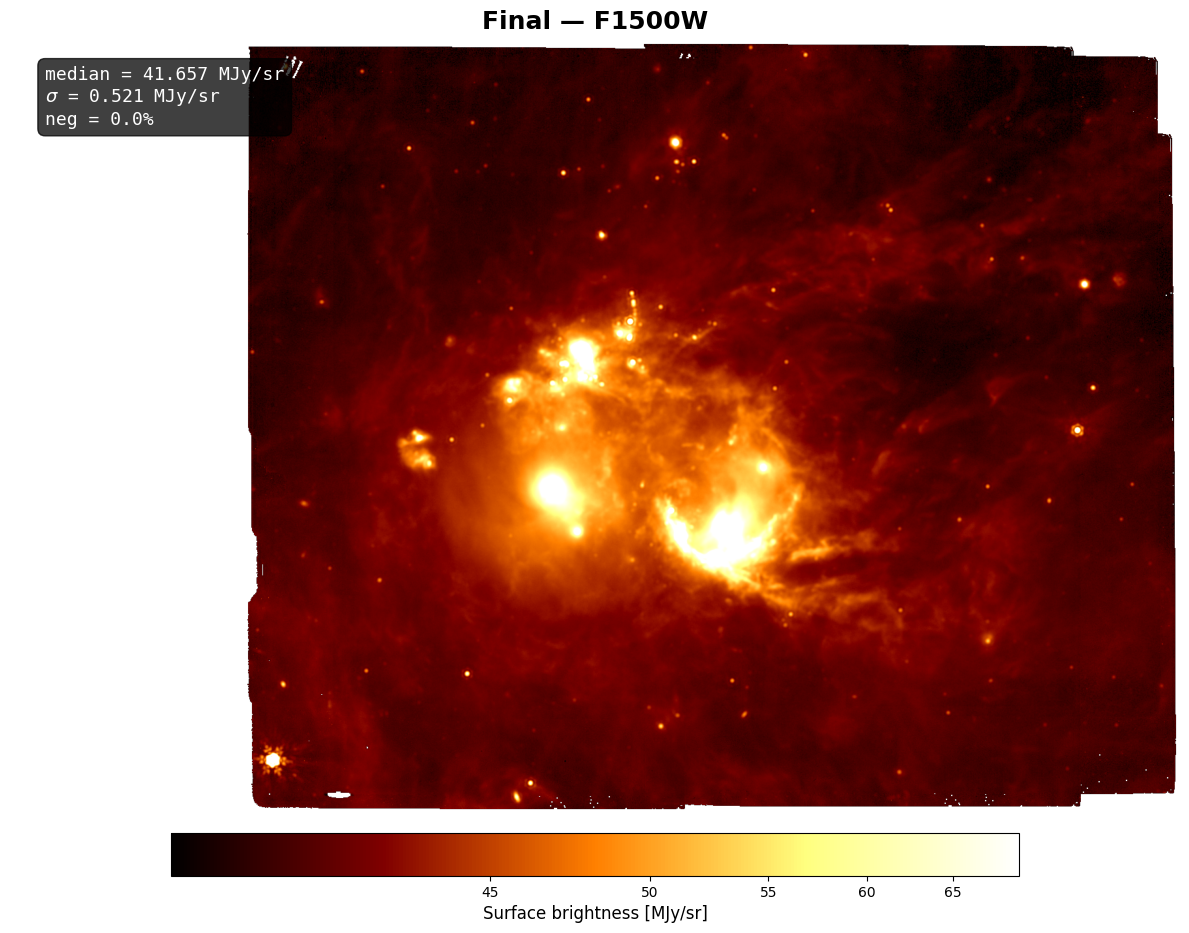

In [8]:
final_sci = load_mosaic(mosaic)
m_ours = get_stats(final_sci)
plot_mosaic(final_sci, f'Final — {FILT}', f'{FILT}_final.png',
            fig_dir=fig_dir, stats_txt=stats_label(*m_ours))

## 7. Comparison with MAST

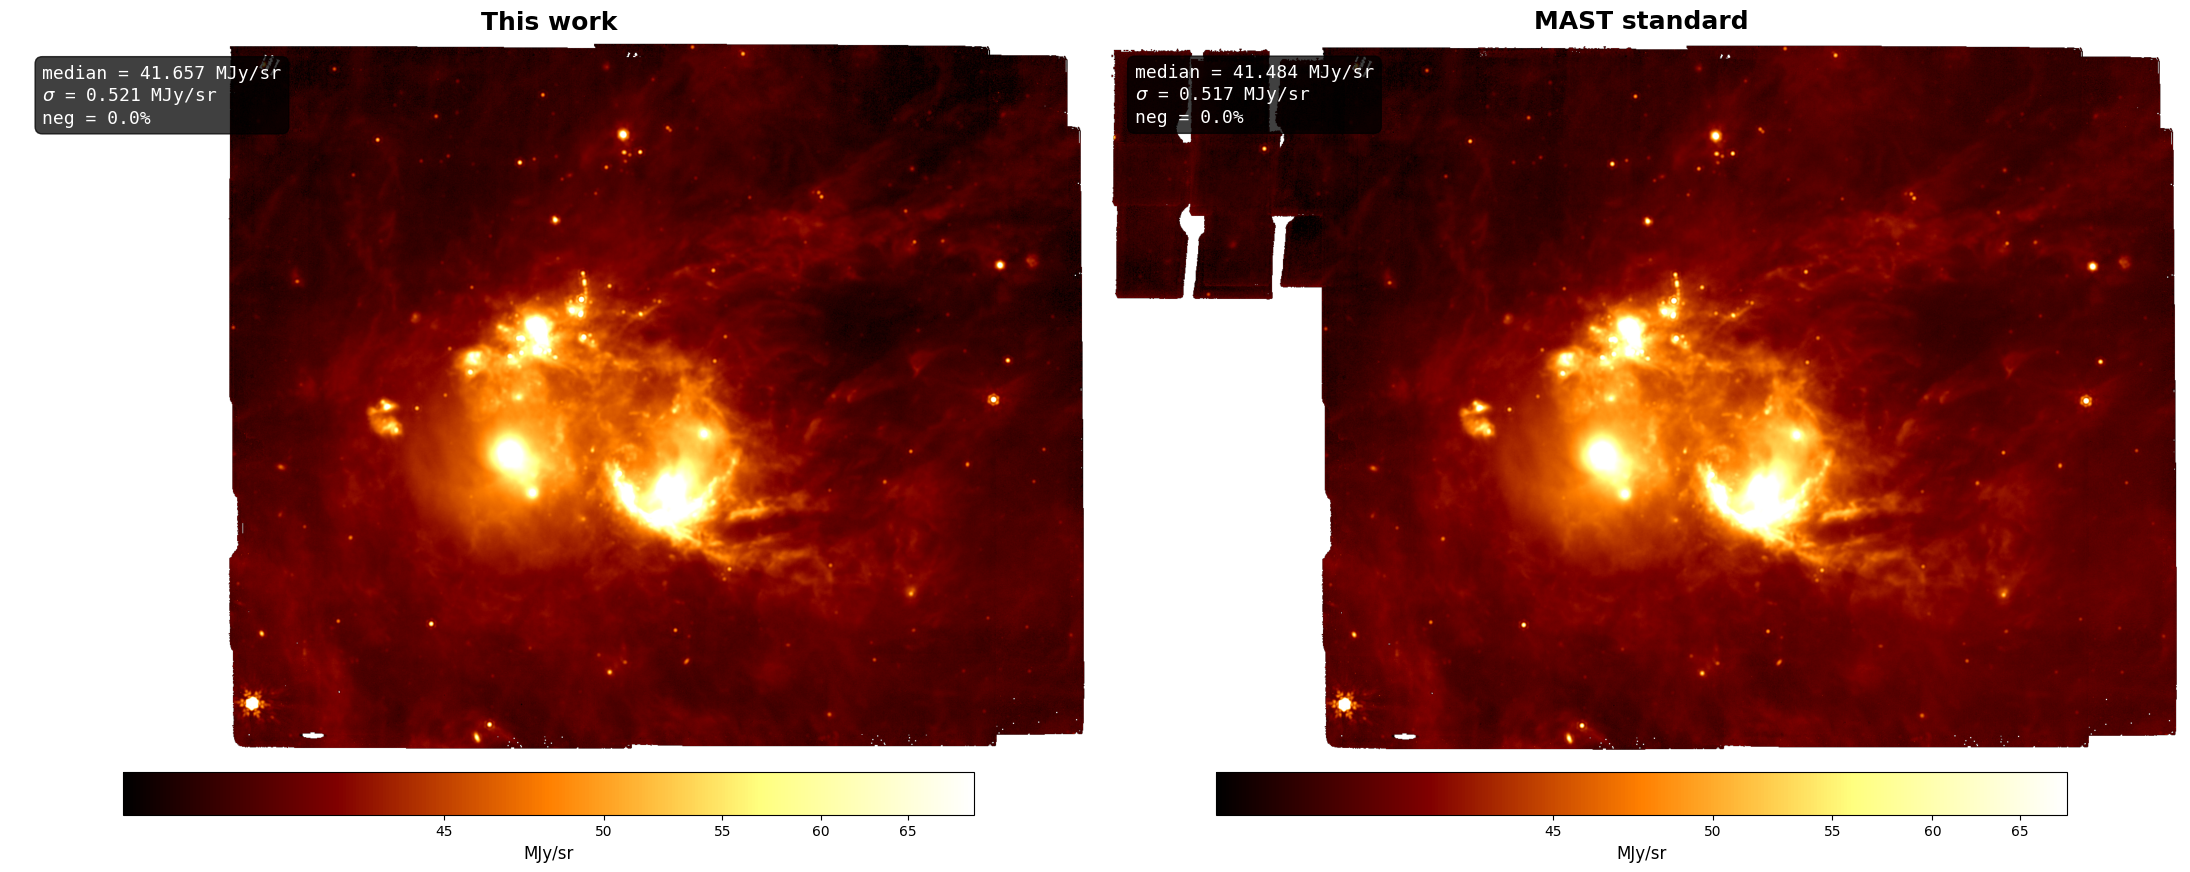

This work: median = 41.657, σ = 0.521 MJy/sr
MAST:      median = 41.484, σ = 0.517 MJy/sr


In [9]:
mast_i2d = sorted(glob.glob(f'{mast_dir}/*_i2d.fits'))
if mast_i2d:
    mast_sci = load_mosaic(mast_i2d[0])
    m_mast = get_stats(mast_sci)

    plot_comparison(final_sci, mast_sci,
                    'This work', 'MAST standard',
                    f'{FILT}_comparison.png', fig_dir=fig_dir,
                    stats1=stats_label(*m_ours), stats2=stats_label(*m_mast))

    print(f'This work: median = {m_ours[0]:.3f}, σ = {m_ours[1]:.3f} MJy/sr')
    print(f'MAST:      median = {m_mast[0]:.3f}, σ = {m_mast[1]:.3f} MJy/sr')
else:
    print('No MAST reference found')

## 8. Summary

In [10]:
line = '=' * 50
tweakreg_str = 'ON' if TWEAKREG else 'OFF'
skymatch_str = 'ON' if SKYMATCH else 'OFF'
skysub_str   = 'ON' if SKY_SUBTRACT else 'OFF'
outlier_str  = 'ON' if OUTLIER_DET else 'OFF'

print(line)
print(f'  {TARGET} ({PROGRAM}) — {FILT}')
print(line)
print()
if 'm_ours' in dir():
    print(f'  Result:')
    print(f'    median = {m_ours[0]:.3f} MJy/sr')
    print(f'    σ = {m_ours[1]:.3f} MJy/sr')
print()
print(f'  WCS shifts (from F560W):')
print(f'    Tile 1: {TILE1_SHIFTS}')
print(f'    Tile 2: {TILE2_SHIFTS}')
print()
print(f'  Stage 1:')
print(f'    IPC:              {"SKIP" if IPC_SKIP else "ON"}')
print(f'    Jump threshold:   {JUMP_THRESHOLD}σ')
print()
print(f'  Lyot flag: row>{LYOT_ROW}, col<{LYOT_COL}')
print()
print(f'  Stage 3:')
print(f'    Pixel scale:      {PIXEL_SCALE} arcsec/pix')
print(f'    Pixfrac:          {PIXFRAC}')
print(f'    Kernel:           {KERNEL}')
print(f'    Tweakreg:         {tweakreg_str}')
print(f'    Skymatch:         {skymatch_str}')
print(f'    Sky subtract:     {skysub_str}')
print(f'    Outlier det:      {outlier_str}')
print(line)

  SMC-SW-Bar-3 (GO-5952) — F1500W

  Result:
    median = 41.657 MJy/sr
    σ = 0.521 MJy/sr

  WCS shifts (from F560W):
    Tile 1: [-0.1674, -0.1364]
    Tile 2: [-0.1584, -0.1352]

  Stage 1:
    IPC:              SKIP
    Jump threshold:   5.0σ

  Lyot flag: row>700, col<310

  Stage 3:
    Pixel scale:      0.11 arcsec/pix
    Pixfrac:          1.0
    Kernel:           square
    Tweakreg:         OFF
    Skymatch:         OFF
    Sky subtract:     OFF
    Outlier det:      ON
